
       MOVIE RECOMMENDATION SYSTEM

Available Movies:
- Avengers
- Iron Man
- Thor
- Captain America
- Spider Man
- Interstellar
- Inception
- The Martian
- Gravity
- Titanic
- The Notebook
- La La Land
- Conjuring
- Annabelle
- John Wick



Enter a movie name:  iron man




              MOVIE DATASET

          Movie           Genre                                     Tags  Rating
       Avengers          Action         action superhero marvel avengers     8.0
       Iron Man          Action       action superhero marvel technology     7.9
           Thor          Action             action superhero marvel thor     7.0
Captain America          Action          action superhero marvel soldier     7.8
     Spider Man          Action           action superhero marvel spider     8.2
   Interstellar Science Fiction   science fiction space adventure future     8.7
      Inception Science Fiction    science fiction dream thriller future     8.8
    The Martian Science Fiction     science fiction space mars adventure     8.0
        Gravity Science Fiction science fiction space astronaut thriller     7.7
        Titanic         Romance                  romance drama ship love     7.9
   The Notebook         Romance          romance drama love relationship     7

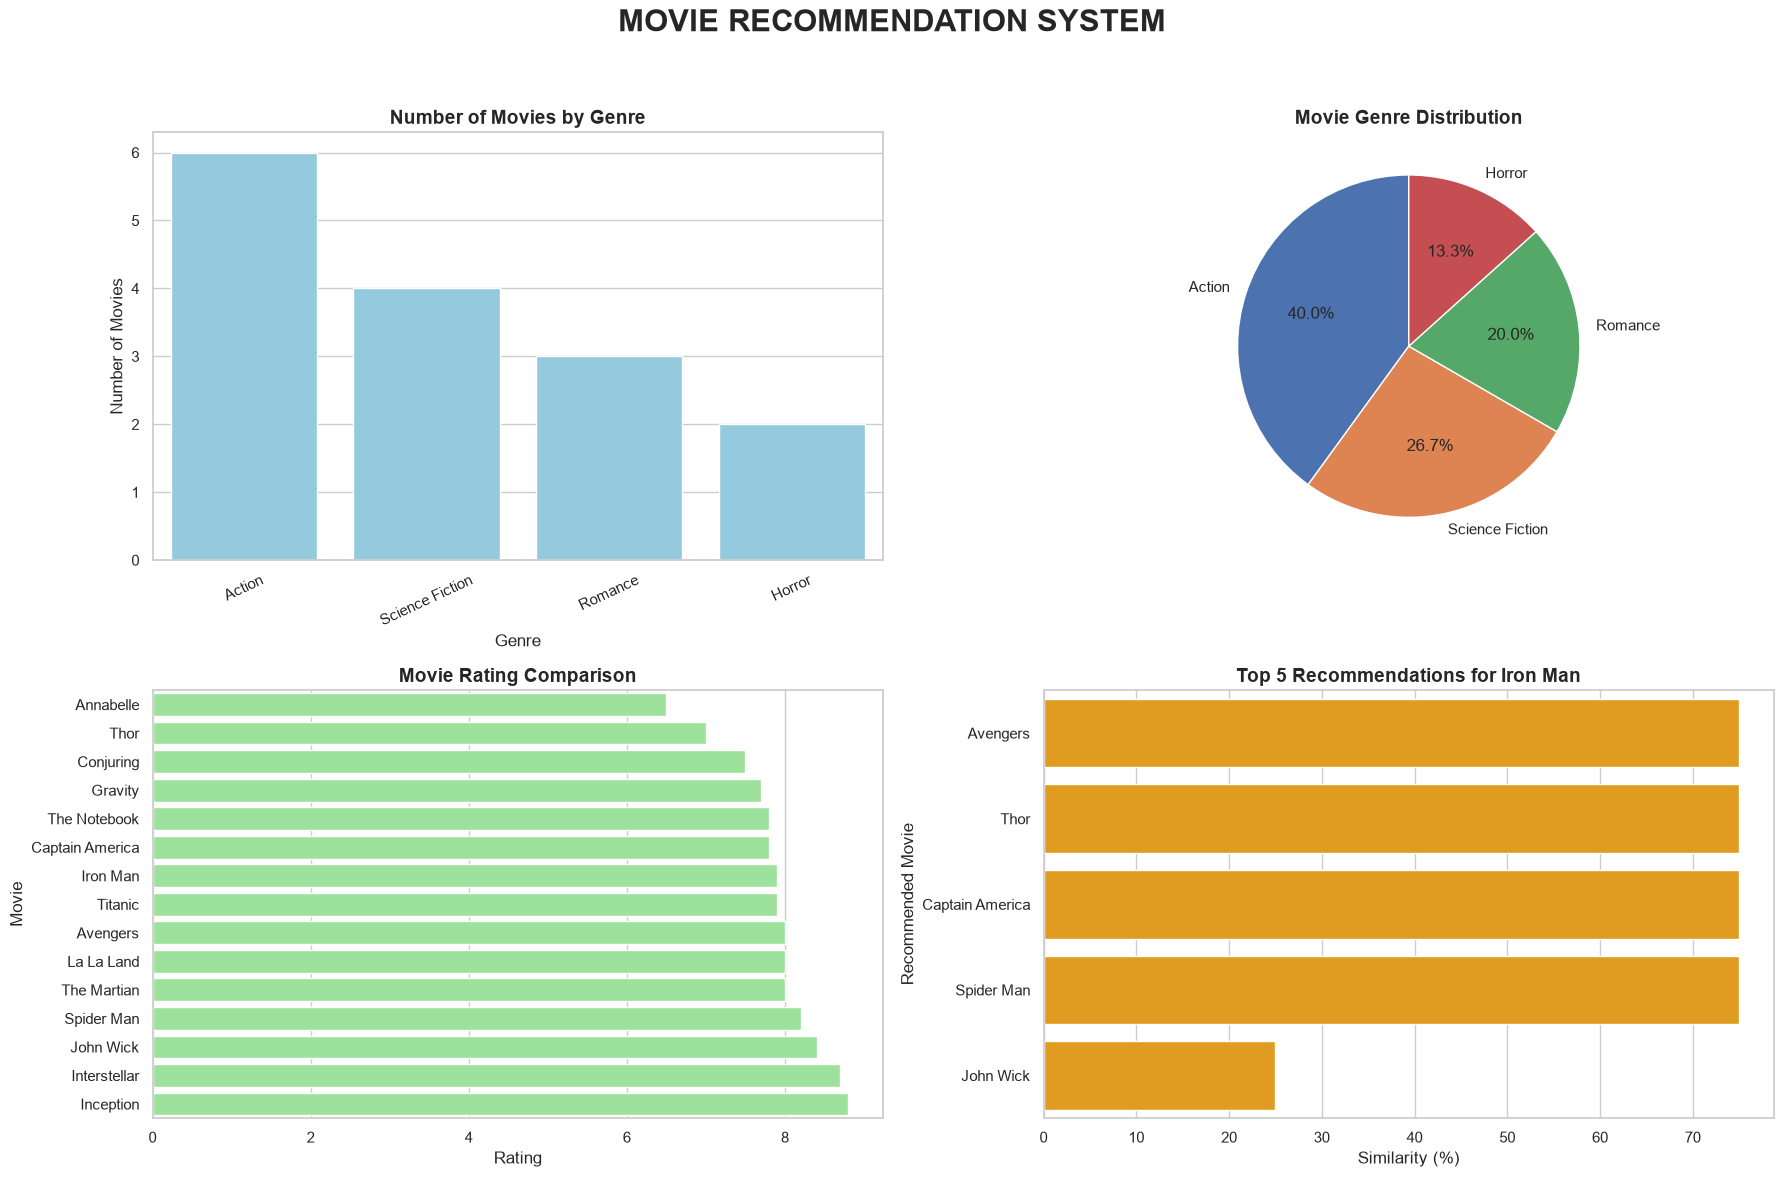



       PROGRAM COMPLETED SUCCESSFULLY


In [1]:
# ============================================================
# MOVIE RECOMMENDATION SYSTEM
# ALL OUTPUT ON ONE PAGE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")


# ============================================================
# 1. CREATE DATASET
# ============================================================

data = {
    "Movie": [
        "Avengers", "Iron Man", "Thor", "Captain America",
        "Spider Man", "Interstellar", "Inception",
        "The Martian", "Gravity", "Titanic",
        "The Notebook", "La La Land", "Conjuring",
        "Annabelle", "John Wick"
    ],

    "Genre": [
        "Action", "Action", "Action", "Action", "Action",
        "Science Fiction", "Science Fiction", "Science Fiction",
        "Science Fiction", "Romance", "Romance", "Romance",
        "Horror", "Horror", "Action"
    ],

    "Tags": [
        "action superhero marvel avengers",
        "action superhero marvel technology",
        "action superhero marvel thor",
        "action superhero marvel soldier",
        "action superhero marvel spider",
        "science fiction space adventure future",
        "science fiction dream thriller future",
        "science fiction space mars adventure",
        "science fiction space astronaut thriller",
        "romance drama ship love",
        "romance drama love relationship",
        "romance music drama love",
        "horror ghost supernatural scary",
        "horror ghost doll supernatural",
        "action crime assassin thriller"
    ],

    "Rating": [
        8.0, 7.9, 7.0, 7.8, 8.2,
        8.7, 8.8, 8.0, 7.7,
        7.9, 7.8, 8.0,
        7.5, 6.5, 8.4
    ]
}

df = pd.DataFrame(data)


# ============================================================
# 2. DATA CLEANING
# ============================================================

df = df.dropna()
df = df.drop_duplicates()
df = df.reset_index(drop=True)


# ============================================================
# 3. BASIC ANALYSIS
# ============================================================

genre_count = df["Genre"].value_counts()

highest_rating = df.loc[df["Rating"].idxmax()]
lowest_rating = df.loc[df["Rating"].idxmin()]


# ============================================================
# 4. COUNT VECTORIZER
# ============================================================

cv = CountVectorizer(stop_words="english")

vectors = cv.fit_transform(df["Tags"]).toarray()


# ============================================================
# 5. COSINE SIMILARITY
# ============================================================

similarity = cosine_similarity(vectors)


# ============================================================
# 6. GET USER INPUT
# ============================================================

print("\n==============================================")
print("       MOVIE RECOMMENDATION SYSTEM")
print("==============================================\n")

print("Available Movies:")

for movie in df["Movie"]:
    print("-", movie)

selected_movie = input(
    "\nEnter a movie name: "
).strip()


# ============================================================
# 7. FIND MOVIE
# ============================================================

if selected_movie.lower() not in df["Movie"].str.lower().values:

    print("\nMovie not found!")
    print("Please enter a valid movie name.")

else:

    index = df[
        df["Movie"].str.lower() == selected_movie.lower()
    ].index[0]

    scores = similarity[index]

    movie_scores = []

    for i in range(len(scores)):

        if i != index:

            movie_scores.append(
                (
                    df.iloc[i]["Movie"],
                    df.iloc[i]["Genre"],
                    scores[i]
                )
            )

    movie_scores = sorted(
        movie_scores,
        key=lambda x: x[2],
        reverse=True
    )

    top_movies = movie_scores[:5]


    # ========================================================
    # 8. RECOMMENDATION DATAFRAME
    # ========================================================

    recommendation_df = pd.DataFrame(
        top_movies,
        columns=[
            "Movie",
            "Genre",
            "Similarity"
        ]
    )

    recommendation_df["Similarity"] = (
        recommendation_df["Similarity"] * 100
    )


    # ========================================================
    # 9. PRINT COMPLETE OUTPUT
    # ========================================================

    print("\n\n==============================================")
    print("              MOVIE DATASET")
    print("==============================================\n")

    print(df.to_string(index=False))


    print("\n\n==============================================")
    print("             DATASET ANALYSIS")
    print("==============================================")

    print("\nDataset Shape :", df.shape)

    print("\nMissing Values:")
    print(df.isnull().sum().to_string())

    print("\nDuplicate Values :", df.duplicated().sum())

    print("\nGenre Count:")
    print(genre_count.to_string())


    print("\n\n==============================================")
    print("              RATING ANALYSIS")
    print("==============================================")

    print("\nHighest Rated Movie")
    print("Movie  :", highest_rating["Movie"])
    print("Rating :", highest_rating["Rating"])

    print("\nLowest Rated Movie")
    print("Movie  :", lowest_rating["Movie"])
    print("Rating :", lowest_rating["Rating"])


    print("\n\n==============================================")
    print("          RECOMMENDATION RESULT")
    print("==============================================")

    print("\nSelected Movie :", df.iloc[index]["Movie"])

    print("\nTOP 5 RECOMMENDED MOVIES\n")

    for number, movie_data in enumerate(
        top_movies,
        start=1
    ):

        print(
            f"{number}. {movie_data[0]} "
            f"| Genre: {movie_data[1]} "
            f"| Similarity: "
            f"{round(movie_data[2] * 100, 2)}%"
        )


    # ========================================================
    # 10. CREATE ONE PAGE WITH ALL GRAPHS
    # ========================================================

    fig = plt.figure(figsize=(18, 12))

    fig.suptitle(
        "MOVIE RECOMMENDATION SYSTEM",
        fontsize=22,
        fontweight="bold"
    )


    # --------------------------------------------------------
    # GRAPH 1 - MOVIES BY GENRE
    # --------------------------------------------------------

    ax1 = plt.subplot(2, 2, 1)

    sns.countplot(
        data=df,
        x="Genre",
        order=genre_count.index,
        color="skyblue",
        ax=ax1
    )

    ax1.set_title(
        "Number of Movies by Genre",
        fontsize=14,
        fontweight="bold"
    )

    ax1.set_xlabel("Genre")
    ax1.set_ylabel("Number of Movies")

    ax1.tick_params(axis="x", rotation=25)


    # --------------------------------------------------------
    # GRAPH 2 - PIE CHART
    # --------------------------------------------------------

    ax2 = plt.subplot(2, 2, 2)

    ax2.pie(
        genre_count.values,
        labels=genre_count.index,
        autopct="%1.1f%%",
        startangle=90
    )

    ax2.set_title(
        "Movie Genre Distribution",
        fontsize=14,
        fontweight="bold"
    )


    # --------------------------------------------------------
    # GRAPH 3 - MOVIE RATINGS
    # --------------------------------------------------------

    ax3 = plt.subplot(2, 2, 3)

    rating_df = df.sort_values(
        "Rating",
        ascending=True
    )

    sns.barplot(
        data=rating_df,
        x="Rating",
        y="Movie",
        color="lightgreen",
        ax=ax3
    )

    ax3.set_title(
        "Movie Rating Comparison",
        fontsize=14,
        fontweight="bold"
    )

    ax3.set_xlabel("Rating")
    ax3.set_ylabel("Movie")


    # --------------------------------------------------------
    # GRAPH 4 - TOP 5 RECOMMENDATIONS
    # --------------------------------------------------------

    ax4 = plt.subplot(2, 2, 4)

    sns.barplot(
        data=recommendation_df,
        x="Similarity",
        y="Movie",
        color="orange",
        ax=ax4
    )

    ax4.set_title(
        "Top 5 Recommendations for "
        + df.iloc[index]["Movie"],
        fontsize=14,
        fontweight="bold"
    )

    ax4.set_xlabel("Similarity (%)")
    ax4.set_ylabel("Recommended Movie")


    # ========================================================
    # 11. ADJUST LAYOUT
    # ========================================================

    plt.tight_layout(
        rect=[0, 0, 1, 0.95]
    )


    # ========================================================
    # 12. SHOW EVERYTHING ON ONE PAGE
    # ========================================================

    plt.show()


# ============================================================
# END
# ============================================================

print("\n\n==============================================")
print("       PROGRAM COMPLETED SUCCESSFULLY")
print("==============================================")